Processed folder: /home/christopher-justin/Downloads/SleepStage/processed_15_all
Subjects: ['Bidslab00', 'Bidslab01', 'Bidslab02', 'Bidslab06', 'Bidslab07', 'Bidslab08', 'Bidslab09', 'Bidslab10', 'Bidslab11', 'Bidslab13', 'Bidslab14', 'Bidslab15', 'Bidslab16', 'Bidslab17', 'Bidslab18', 'Bidslab19', 'Bidslab20', 'Bidslab22', 'Bidslab30', 'Bidslab31', 'Bidslab32', 'Bidslab34', 'Bidslab35', 'Bidslab36', 'Bidslab38', 'Bidslab39', 'Bidslab40', 'Bidslab41', 'Bidslab42', 'Bidslab43', 'Bidslab44', 'Bidslab45', 'Bidslab47', 'Bidslab49', 'Bidslab50', 'Bidslab51', 'Bidslab52', 'Bidslab53', 'Bidslab55', 'Bidslab56', 'Bidslab60', 'Bidslab62', 'Bidslab63', 'Bidslab64', 'Bidslab65', 'Bidslab66', 'Bidslab68']
Labels: {'N1': 88124, 'N3': 51631, 'N2': 37623, 'Wake': 21482}


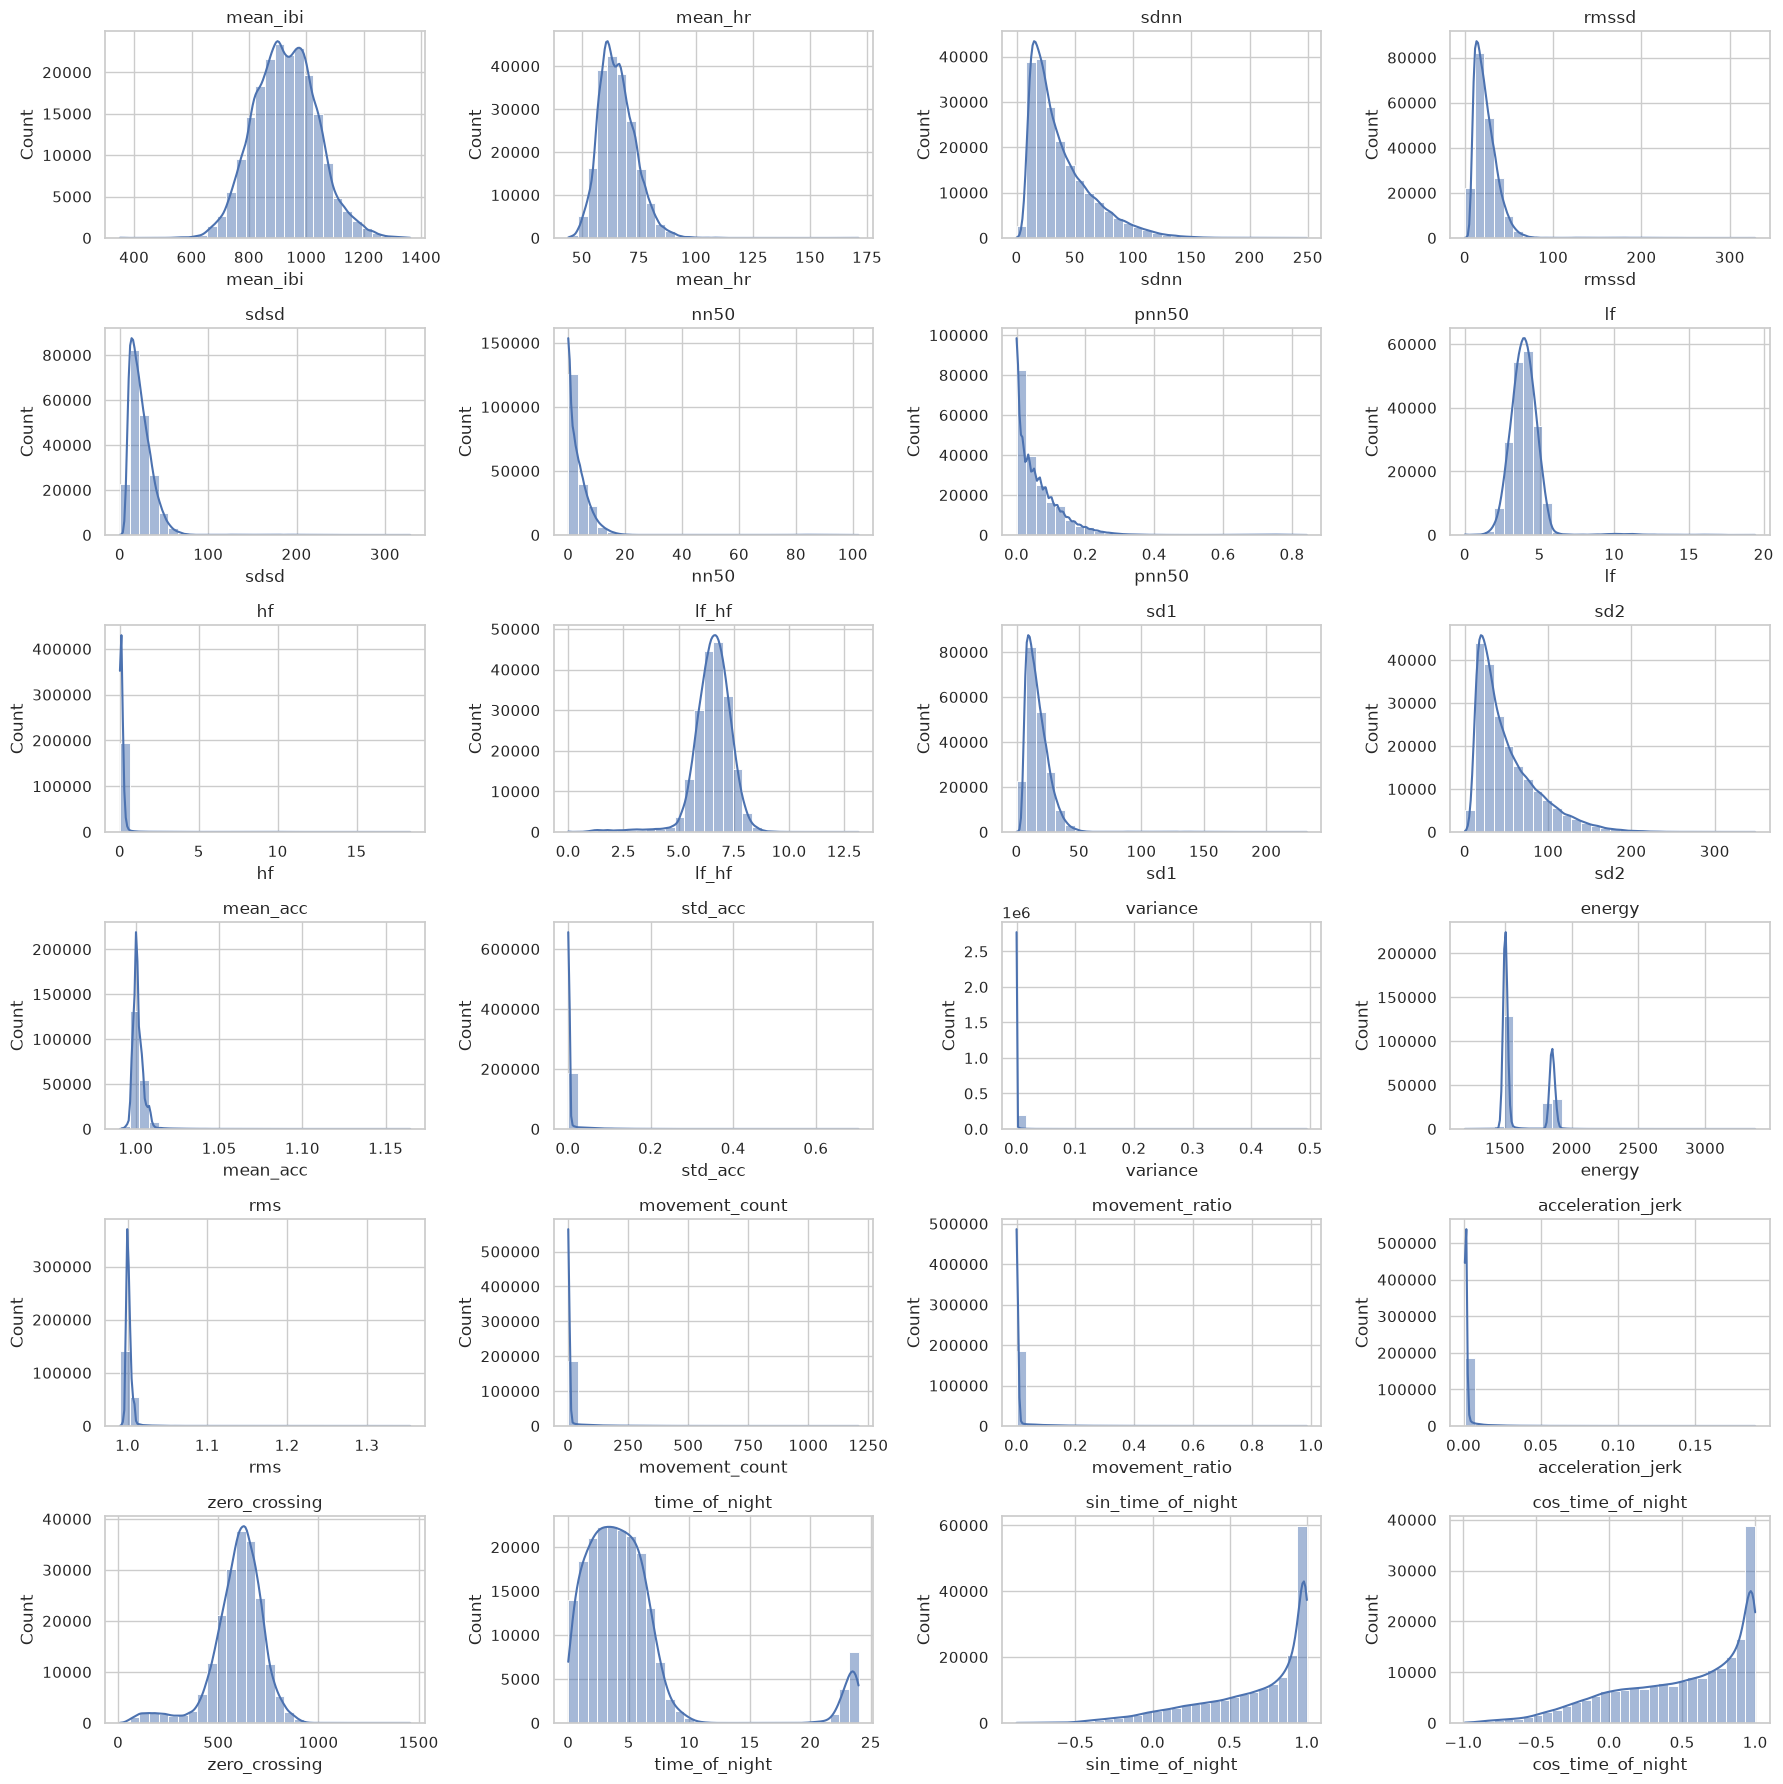

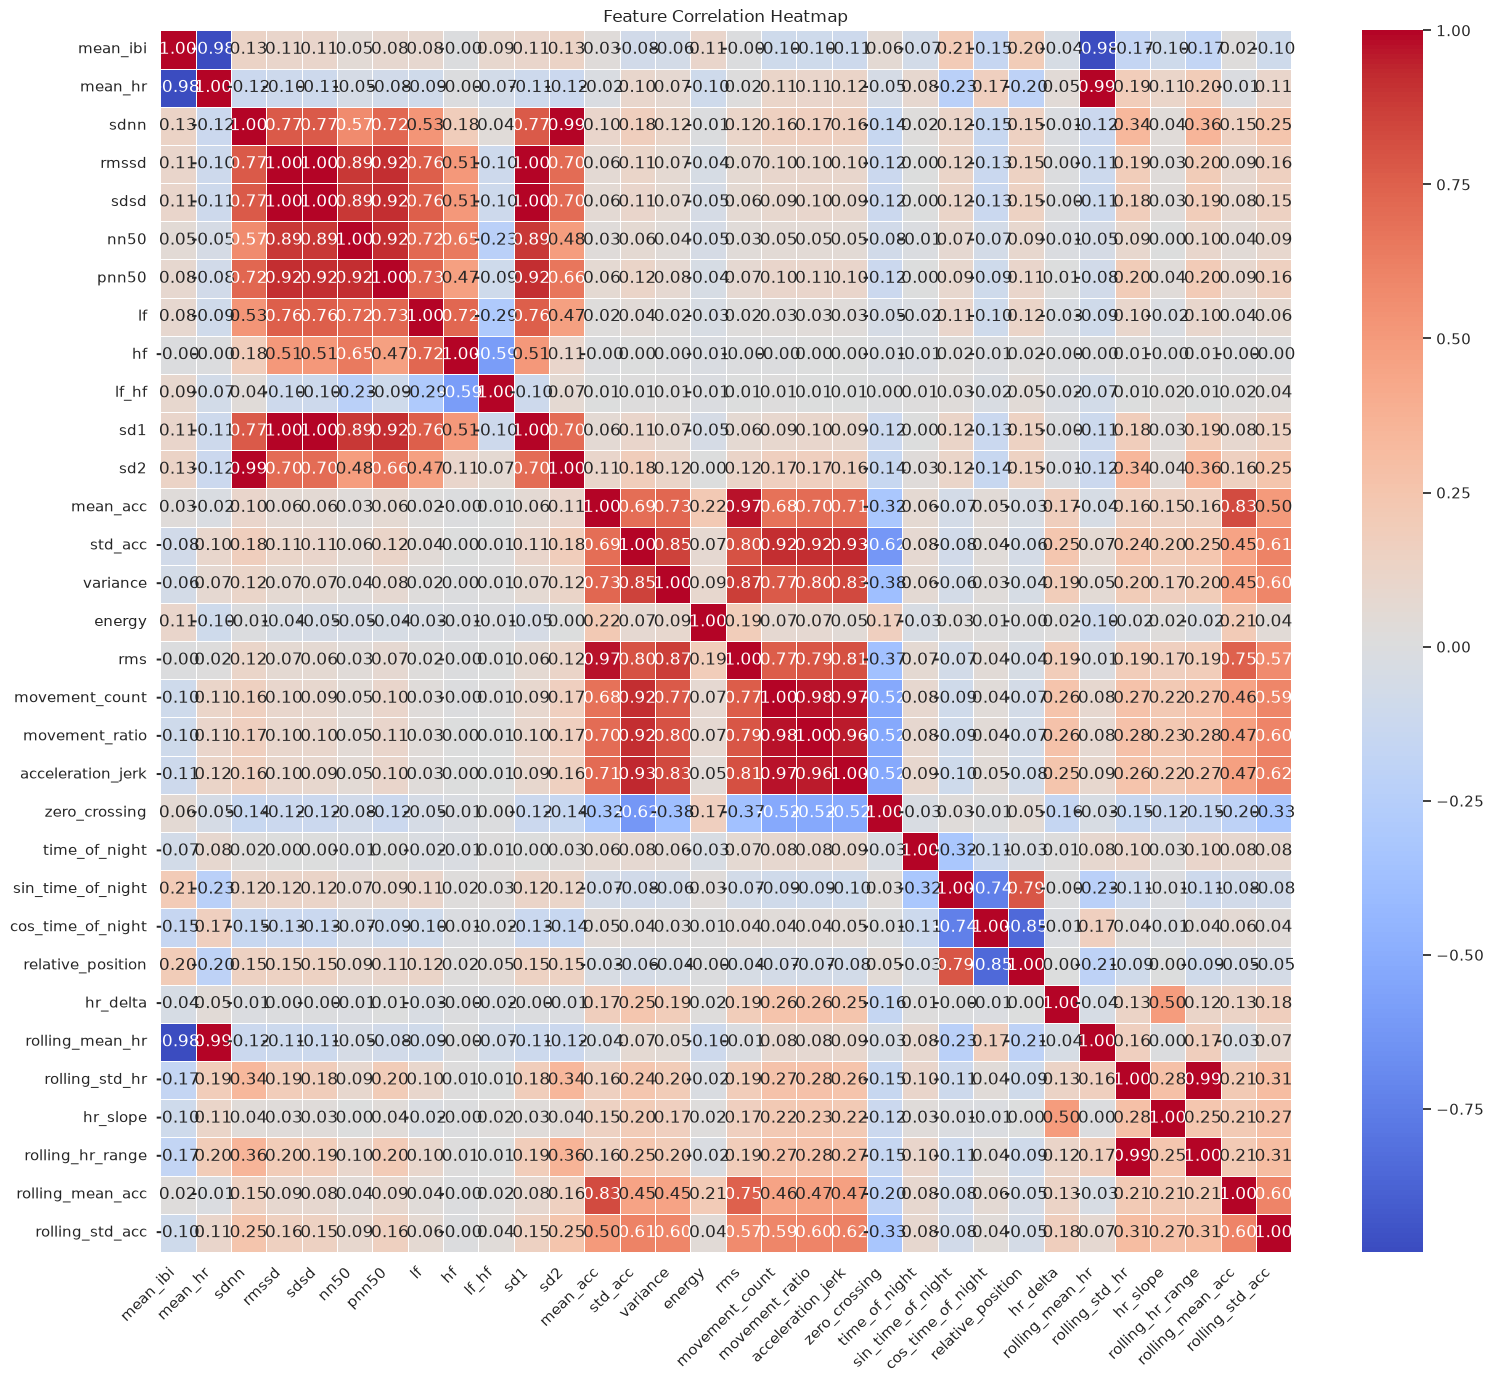

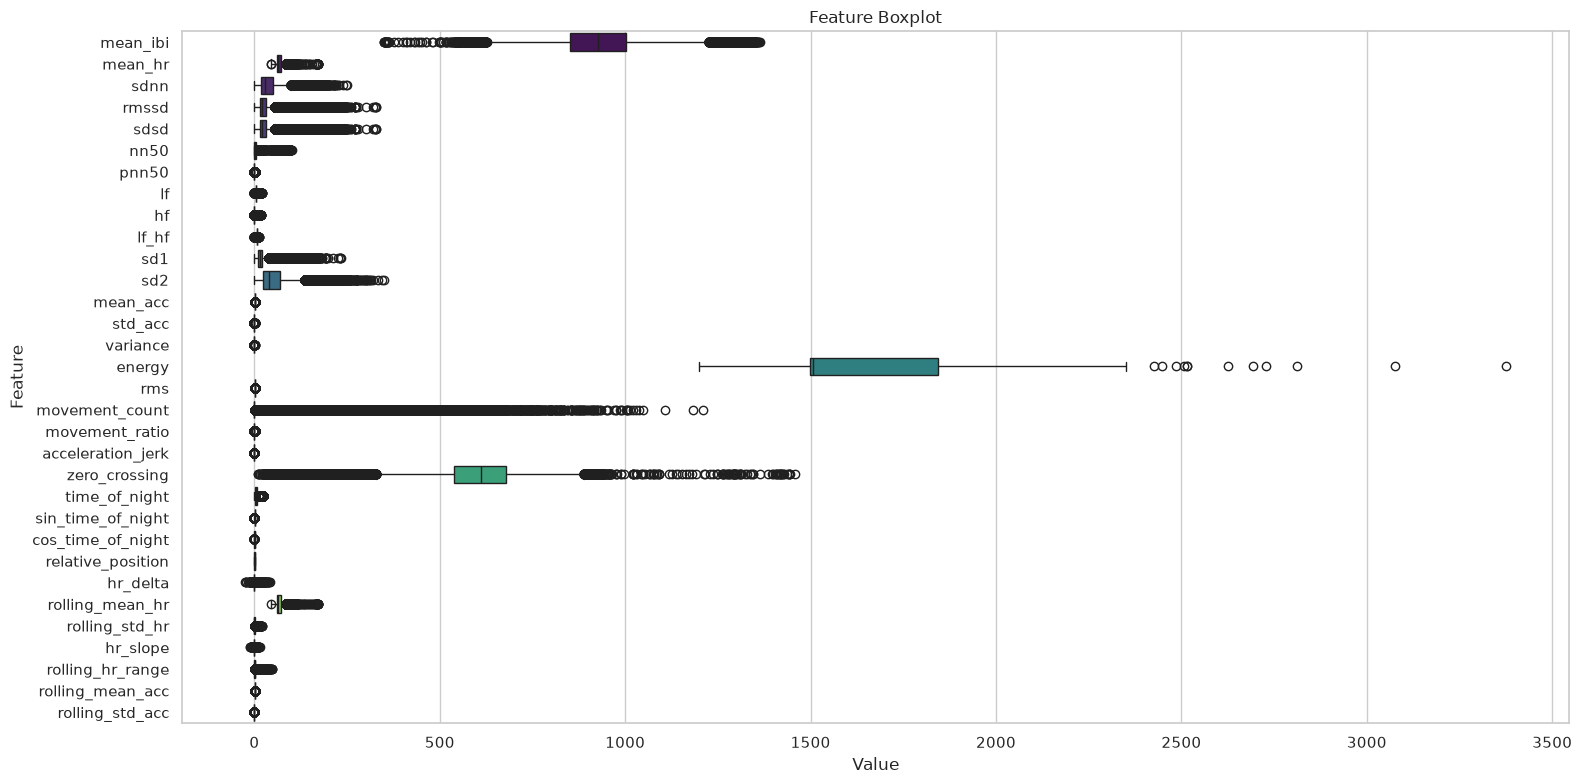

,missing_count,missing_pct
mean_ibi,0,0.0
mean_hr,0,0.0
rolling_mean_acc,0,0.0
rolling_hr_range,0,0.0
hr_slope,0,0.0
rolling_std_hr,0,0.0
rolling_mean_hr,0,0.0
hr_delta,0,0.0
relative_position,0,0.0
cos_time_of_night,0,0.0


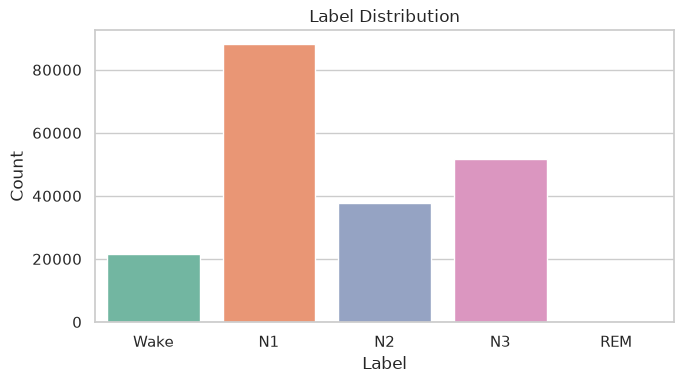

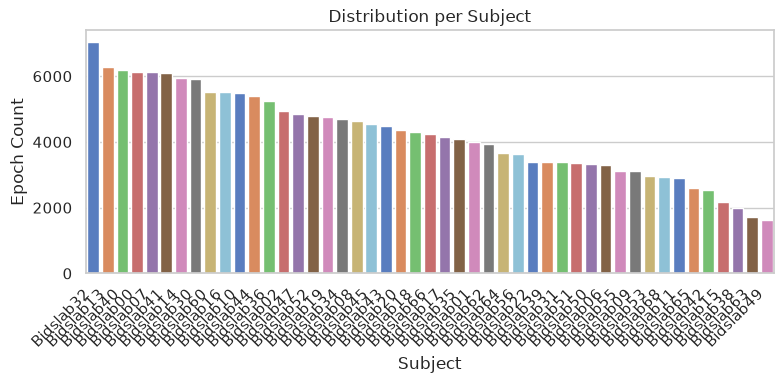

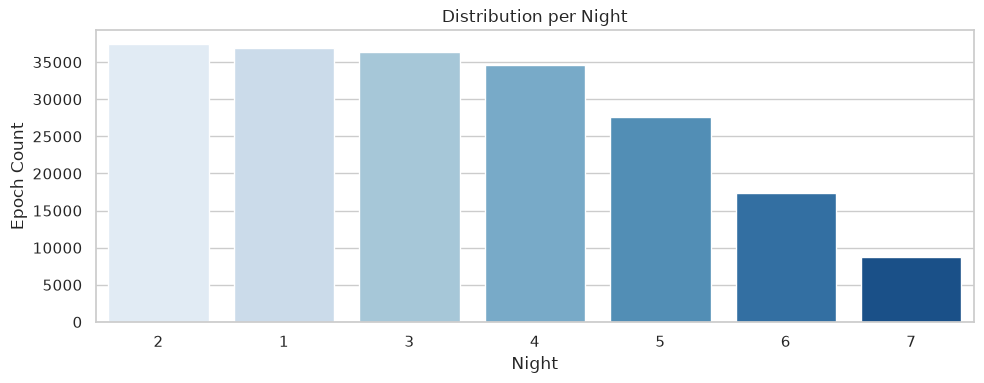

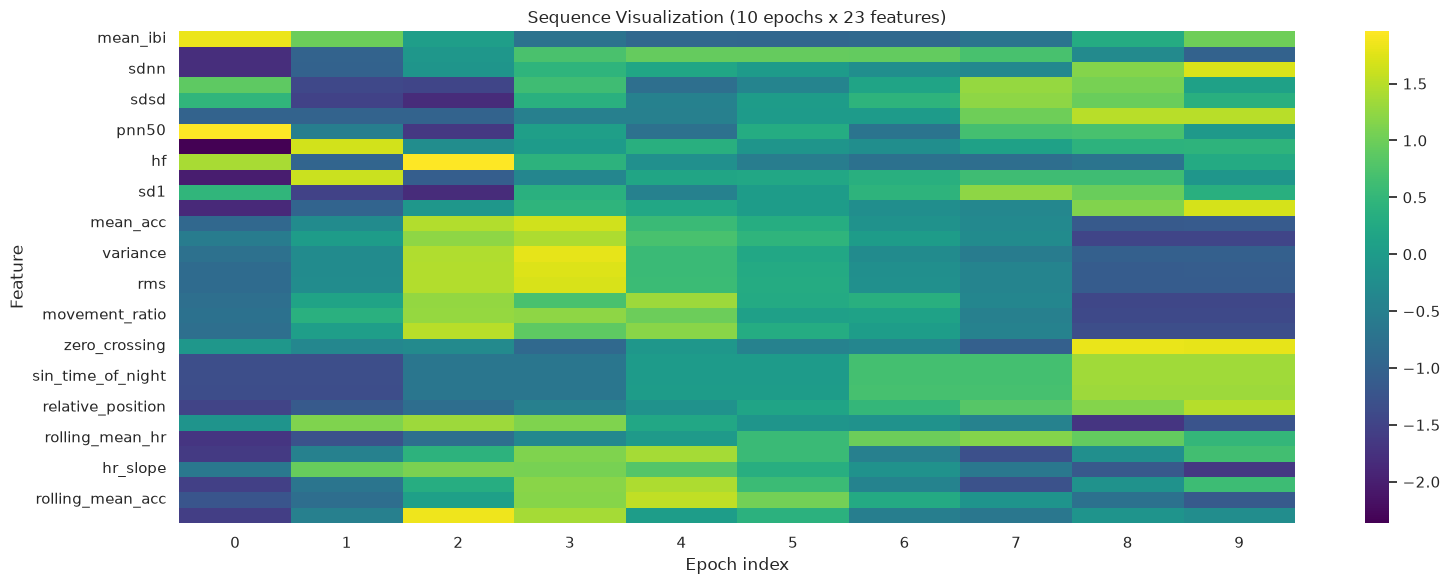

In [ ]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

project_root = Path.cwd()
for candidate in [project_root, project_root / "Analysis", project_root.parent]:
    if (candidate / "processed").exists():
        project_root = candidate
        break

processed_dir = project_root / "processed_15_all"
fig_dir = project_root / "Analysis" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

feature_names_path = processed_dir / "feature_names.json"
X_path = processed_dir / "X.npy"
metadata_path = processed_dir / "metadata.csv"
y_path = processed_dir / "y.npy"

if not feature_names_path.exists() or not X_path.exists():
    raise FileNotFoundError(
        "File feature_names.json atau X.npy tidak ditemukan di folder processed. Jalankan build_all_processed_dataset.py terlebih dahulu."
    )

with open(feature_names_path, "r", encoding="utf-8") as f:
    feature_names = json.load(f)

X = np.load(X_path)
y = np.load(y_path)

if X.ndim == 3:
    X = X.reshape(-1, X.shape[2])
elif X.ndim == 1:
    X = X.reshape(-1, 1)

if len(feature_names) != X.shape[1]:
    raise ValueError(
        f"Jumlah fitur ({len(feature_names)}) tidak cocok dengan dimensi X ({X.shape[1]})."
    )

feature_df = pd.DataFrame(X, columns=feature_names)
metadata = pd.read_csv(metadata_path)
if len(metadata) != len(feature_df):
    raise ValueError(f"Jumlah baris metadata ({len(metadata)}) tidak cocok dengan fitur ({len(feature_df)}).")

feature_df = pd.concat(
    [feature_df, metadata[["Subject", "Night", "Epoch"]].reset_index(drop=True)],
    axis=1,
)

label_map = {0: "Wake", 1: "N1", 2: "N2", 3: "N3", 4: "REM"}
feature_df["label"] = y.astype(int)
feature_df["label_name"] = feature_df["label"].map(label_map)

feature_cols = [
    col for col in feature_df.columns
    if col not in {"Subject", "Night", "Epoch", "label", "label_name"}
]
feature_df[feature_cols] = feature_df[feature_cols].apply(pd.to_numeric, errors="coerce")
print("Processed folder:", processed_dir)
print("Subjects:", sorted(feature_df["Subject"].unique().tolist()))
print("Labels:", feature_df["label_name"].value_counts().to_dict())

# 1. Histogram seluruh 23 fitur
fig, axes = plt.subplots(6, 4, figsize=(18, 18))
axes = axes.ravel()
for ax, col in zip(axes, feature_cols):
    sns.histplot(feature_df[col].dropna(), bins=30, kde=True, ax=ax)
    ax.set_title(col)
for ax in axes[len(feature_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(fig_dir / "01_feature_histograms.png", dpi=200, bbox_inches="tight")
plt.show()

# 2. Heatmap korelasi 23x23
corr_matrix = feature_df[feature_cols].corr(method="pearson")
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, cbar=True, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(fig_dir / "02_feature_correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

# 3. Boxplot semua fitur
fig, ax = plt.subplots(figsize=(16, 8))
sns.boxplot(data=feature_df[feature_cols], orient="h", palette="viridis", ax=ax)
ax.set_title("Feature Boxplot")
ax.set_xlabel("Value")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(fig_dir / "03_feature_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

# 4. Missing value report
missing_report = pd.DataFrame({
    "missing_count": feature_df[feature_cols].isna().sum(),
    "missing_pct": feature_df[feature_cols].isna().mean() * 100.0,
}).sort_values("missing_count", ascending=False)
display(missing_report)
missing_report.to_csv(fig_dir / "04_missing_value_report.csv")

# 5. Distribusi label
fig, ax = plt.subplots(figsize=(7, 4))
label_order = ["Wake", "N1 & N2", "N3", "REM"]
sns.countplot(data=feature_df, x="label_name", order=label_order, palette="Set2", ax=ax)
ax.set_title("Label Distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(fig_dir / "05_label_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

# 6. Distribusi per subject
fig, ax = plt.subplots(figsize=(8, 4))
subject_order = feature_df["Subject"].value_counts().index
sns.countplot(data=feature_df, x="Subject", order=subject_order, palette="muted", ax=ax)
ax.set_title("Distribution per Subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Epoch Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(fig_dir / "06_subject_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

# 7. Distribusi per night
fig, ax = plt.subplots(figsize=(10, 4))
night_order = feature_df["Night"].value_counts().index
sns.countplot(data=feature_df, x="Night", order=night_order, palette="Blues", ax=ax)
ax.set_title("Distribution per Night")
ax.set_xlabel("Night")
ax.set_ylabel("Epoch Count")
plt.tight_layout()
plt.savefig(fig_dir / "07_night_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

# 8. Visualisasi sequence (10 epoch x 23 fitur)
sequence_df = feature_df.sort_values(["Subject", "Night", "Epoch"]).head(10)[feature_cols].copy()
if not sequence_df.empty:
    standardized = sequence_df.apply(lambda col: (col - col.mean()) / col.std() if col.std() else 0.0)
    fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(standardized.T, cmap="viridis", cbar=True, ax=ax)
ax.set_title("Sequence Visualization (10 epochs x 23 features)")
ax.set_xlabel("Epoch index")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(fig_dir / "08_sequence_visualization.png", dpi=200, bbox_inches="tight")

plt.show()
plt.show()
